This is a notebook for computing deep foundation geotechnical axial capacity with rock strata. <br>
Author: Zhiyan Jiang [(linkedin.com/in/zhiyanjiang)](http://www.linkedin.com/in/zhiyanjiang)

In [1]:
%load_ext autoreload
%autoreload 2

Built-in and third-party libraries

In [2]:
import logging

import yaml

Local libraries

In [ ]:
from nb_utils import find_project_root

from deep_foundation_bearing_capacity.cross_sections.cross_sections import CircularSection
from deep_foundation_bearing_capacity.factor_of_safety.factor_of_safety import FactorOfSafetyDeepFoundation
from deep_foundation_bearing_capacity.foundation.deep_foundation import DeepFoundation
from deep_foundation_bearing_capacity.foundation.foundation_material import FoundationConcrete
from deep_foundation_bearing_capacity.geomaterials.layer import Layer
from deep_foundation_bearing_capacity.geomaterials.rock import Rock
from deep_foundation_bearing_capacity.geomaterials.soil import Soil
from deep_foundation_bearing_capacity.segments.segments import Segment
from deep_foundation_bearing_capacity.segments.unit_resistance import (
    EndResistance,
    SideResistance,
    SideResistanceContext,
)

Project environment setup

In [4]:
PROJECT_ROOT = find_project_root()

logging.basicConfig(level = logging.WARNING)

Read soil material parameters from YAML

In [ ]:
# Read rock parameters from YAML
with open(PROJECT_ROOT/"notebooks/data/soil_params.yaml") as f:
    soils_dict = yaml.safe_load(f)

soil_list = []
for soil_dict in soils_dict:
    soil = Soil.from_dict(soil_dict)
    soil_list.append(soil)

    soil.display_properties()
    print()  

soil_index is: 0
unit_weight is: 120.0
cohesion is: 0.0
friction_angle is: 30.0
n60 is: 5

soil_index is: 1
unit_weight is: 120.0
cohesion is: 500.0
friction_angle is: 0.0
n60 is: 6

soil_index is: 2
unit_weight is: 115.0
cohesion is: 0.0
friction_angle is: 30.0
n60 is: 10

soil_index is: 3
unit_weight is: 115.0
cohesion is: 2000.0
friction_angle is: 0.0
n60 is: 6

soil_index is: 4
unit_weight is: 130.0
cohesion is: 0.0
friction_angle is: 30.0
n60 is: 19

soil_index is: 5
unit_weight is: 130.0
cohesion is: 4000.0
friction_angle is: 0.0
n60 is: 19

soil_index is: 6
unit_weight is: 130.0
cohesion is: 0.0
friction_angle is: 30.0
n60 is: 26

soil_index is: 7
unit_weight is: 130.0
cohesion is: 200.0
friction_angle is: 0.0
n60 is: 26

soil_index is: 8
unit_weight is: 130.0
cohesion is: 0.0
friction_angle is: 30.0
n60 is: 20

soil_index is: 9
unit_weight is: 130.0
cohesion is: 8000.0
friction_angle is: 0.0
n60 is: 20

soil_index is: 10
unit_weight is: 115.0
cohesion is: 0.0
friction_angle is:

Read rock material parameters from YAML

In [ ]:
# Read rock parameters from YAML
with open(PROJECT_ROOT/"notebooks/data/rock_params.yaml") as f:
    rocks_dict = yaml.safe_load(f)

rock_list = []
for rock_dict in rocks_dict:
    rock = Rock.from_dict(rock_dict)
    rock_list.append(rock)

    rock.display_properties()
    print()    

rock_index is: 0
unit_weight is: 150.0
friction_angle is: 30.0
qu is: 10000.0
rqd is: 100.0
rock_type is: A
rock_quality is: Excellent
rock_type_advanced is: None
joint is: open

rock_index is: 1
unit_weight is: 150.0
friction_angle is: 27.0
qu is: 10000.0
rqd is: 100.0
rock_type is: A
rock_quality is: Excellent
rock_type_advanced is: igm_cohesive
joint is: open

rock_index is: 2
unit_weight is: 150.0
friction_angle is: 30.0
qu is: 10000.0
rqd is: 90.0
rock_type is: A
rock_quality is: Very good
rock_type_advanced is: igm_cohesive
joint is: open



Read layer parameters from YAML

In [7]:
with open(PROJECT_ROOT/"data/layer_params1.yaml") as f:
    layers_dict = yaml.safe_load(f)

layer_list = []
for layer_dict in layers_dict:
    layer = Layer.from_dict(layer_dict)
    layer_list.append(layer)

Manually assign geomaterial to each layer

In [8]:
layer_list[0].geomaterial = soil_list[0]
layer_list[1].geomaterial = rock_list[1]
layer_list[2].geomaterial = rock_list[2]

for layer in layer_list:
    layer.display_properties(display_geomaterial=True)
    print()

layer_index is: 0
ground_water_depth is: 15.0
top_depth is: 0
thickness is: 10
soil_index is: 0
unit_weight is: 120.0
cohesion is: 0.0
friction_angle is: 30.0
n60 is: 5

layer_index is: 1
ground_water_depth is: 15.0
top_depth is: 10
thickness is: 5
rock_index is: 1
unit_weight is: 150.0
friction_angle is: 27.0
qu is: 10000.0
rqd is: 100.0
rock_type is: A
rock_quality is: Excellent
rock_type_advanced is: igm_cohesive
joint is: open

layer_index is: 2
ground_water_depth is: 15.0
top_depth is: 15
thickness is: 10
rock_index is: 2
unit_weight is: 150.0
friction_angle is: 30.0
qu is: 10000.0
rqd is: 90.0
rock_type is: A
rock_quality is: Very good
rock_type_advanced is: igm_cohesive
joint is: open



Test SideResistance Class

In [9]:
# first layer
side_resistance_context_1 = SideResistanceContext(effective_stress = 600)
side_resistance_obj_1 = SideResistance.for_material(layer_list[0])
print(f"First layer side resistance is: {side_resistance_obj_1.side_resistance_unit(side_resistance_context_1):.2f}")

# second layer
side_resistance_context_2 = SideResistanceContext(effective_stress = 1575)
side_resistance_obj_2 = SideResistance.for_material(layer_list[1])
print(f"Second layer side resistance is: {side_resistance_obj_2.side_resistance_unit(side_resistance_context_2):.2f}")

# third layer
side_resistance_context_3 = SideResistanceContext(effective_stress = 1288)
side_resistance_obj_3 = SideResistance.for_material(layer_list[2])
print(f"Third layer side resistance is: {side_resistance_obj_3.side_resistance_unit(side_resistance_context_3):.2f}")


First layer side resistance is: 239.51
Second layer side resistance is: 1515.51
Third layer side resistance is: 1515.22


Test EndResistance class

In [10]:
# First, second, and third layer
end_resistance_obj_1 = EndResistance.for_material(layer_list[0])
print(f"Top layer unit end resistance is: {end_resistance_obj_1.end_resistance_unit(layer_list[0]):.2f}")

end_resistance_obj_2 = EndResistance.for_material(layer_list[1])
print(f"Second layer unit end resistance is: {end_resistance_obj_2.end_resistance_unit(layer_list[0]):.2f}")

end_resistance_obj_3 = EndResistance.for_material(layer_list[2])
print(f"Third layer unit end resistance is: {end_resistance_obj_3.end_resistance_unit(layer_list[0]):.2f}")

Top layer unit end resistance is: 6000.00
Second layer unit end resistance is: 38284.27
Third layer unit end resistance is: 14147.71


Test CrossSection class

In [11]:
cross_section_diameter = 1.5
cross_section_obj = CircularSection(cross_section_diameter)
cross_section_obj.display_properties()

CROSS_SECTION_NAME is: Circular Section
diameter is: 1.5
perimeter is: 4.71238898038469
area is: 1.7671458676442586


Test Segment class

In [12]:
segment_obj_list = []
foundation_concrete_obj = FoundationConcrete()

for layer in layer_list:
    segment_obj = Segment(cross_section_obj, layer, foundation_concrete_obj)
    segment_obj_list.append(segment_obj)

print(f"Top segment side surface area is: {segment_obj_list[0].side_surface_area:.2f}")

Top segment side surface area is: 47.12


Test FactorOfSafety class

In [13]:
fs = 1.0
fs_obj = FactorOfSafetyDeepFoundation(fs, fs)
print(f"Factor of safety for side_compression is prescribed as: {fs_obj.fs_side_compression}")
print(f"Factor of safety for side_uplift is prescribed as: {fs_obj.fs_side_uplift}")
print(f"Factor of safety for end is prescribed as: {fs_obj.fs_end}")

Factor of safety for side_compression is prescribed as: 1.0
Factor of safety for side_uplift is prescribed as: 1.0
Factor of safety for end is prescribed as: 1.0


Test DeepFoundation class

In [14]:
top_depth = 0
deep_foundation_obj = DeepFoundation(segment_obj_list, top_depth,  resistance_corrections = None, fs = fs_obj)

# test DeepFoundation method for self weight
print(f"Concrete foundation self weight is: {deep_foundation_obj.effective_weight:.0f} lb.")
# test DeepFoundation method for calculating effective stress
print(f"Deep foundation effective stresses are: {deep_foundation_obj.calculate_segment_effective_stresses}")

Concrete foundation self weight is: 5524 lb.
Deep foundation effective stresses are: [600.0, 1575.0, 2388.0]


Test DeepFoundation side resistance 

In [15]:
# for compression
print("Below is compressive side resistance (lb.):")
print(deep_foundation_obj.calculate_segment_side_resistances(uplift = False))
print()
# for uplift
print("Below is uplift side resistance (lb.):")
print(deep_foundation_obj.calculate_segment_side_resistances(uplift = True))


Below is compressive side resistance (lb.):
[11286.610166545004, np.float64(35708.38873555117), np.float64(71402.93755085196)]

Below is uplift side resistance (lb.):
[8464.957624908753, np.float64(35708.38873555117), np.float64(71402.93755085196)]


Test DeepFoundation accumulative side resistance + end resistance

In [16]:
print("Check below for side + end ?= compression total")
for segment_side_resistance_accumulative, segment_end_resistance, segment_total in zip(
deep_foundation_obj.calculate_segment_side_resistances_accumulative(),
deep_foundation_obj.calculate_segment_end_resistances(),
deep_foundation_obj.calculate_compression_resistances_accumulative()
):
    print(f"{segment_side_resistance_accumulative:.0f} + {segment_end_resistance:.0f} ?= {segment_total:.0f}")

Check below for side + end ?= compression total
11287 + 10603 ?= 21889
46995 + 67654 ?= 114649
118398 + 25001 ?= 143399


Test DeepFoundation calculate_segment_weights_accumulative

In [17]:
print("Accumulative self weight is: ")
deep_foundation_obj.calculate_segment_weights_effective_accumulative()

Accumulative self weight is: 


[2650.718801466388, 3976.078202199582, 5524.097982255953]

Test DeepFoundation accumulative uplift resistance

In [18]:

print("Accumulative uplift resistance is uplift side resistance + self weight:")
for temp in deep_foundation_obj.calculate_uplift_resistances_accumulative():
    print(f"{temp:.0f} lb.")


Accumulative uplift resistance is uplift side resistance + self weight:
11116 lb.
48149 lb.
121100 lb.


Test visualization of compression

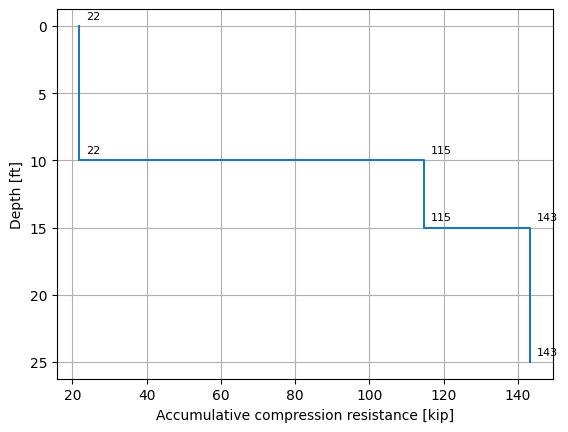

In [19]:
# piecewise plot
deep_foundation_obj.visualize_resistances_accumulative(target = "compression", style = "piecewise")

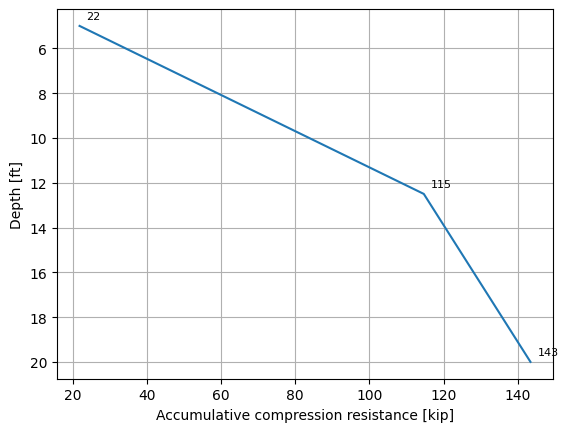

In [20]:
# midpoint plot
deep_foundation_obj.visualize_resistances_accumulative(target = "compression", style = "mid")

Test visualization of uplift accumulative resistance

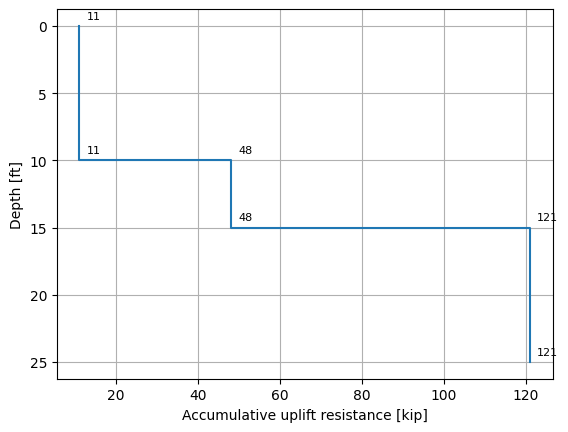

In [21]:
# piecewise plot
deep_foundation_obj.visualize_resistances_accumulative(target = "uplift", style = "piecewise")


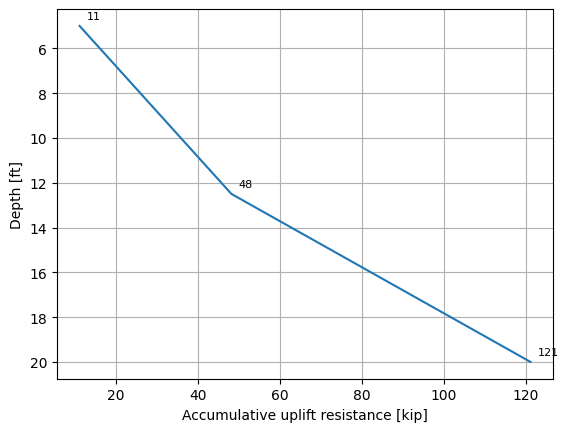

In [22]:
# midpoint plot
deep_foundation_obj.visualize_resistances_accumulative(target = "uplift", style = "mid")

Test structural compression capacity

In [23]:
print("Each segment's structural capacity in compression is: ")
print(deep_foundation_obj.segments_structural_capacity_compression())

Each segment's structural capacity in compression is: 
[335899.0865218207, 335899.0865218207, 335899.0865218207]
